In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt?
import matplotlib.patches as patches

In [73]:
class Problem(ABC):
    '''Abtract class for a search problem'''
    @abstractmethod
    def initial_state(self) -> Any:
        '''Return the start state'''
        pass
    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        '''Return True if state is a goal state.'''
        pass
    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        '''Return the legal actions available in the given state.'''
        pass
    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        '''Return the next state after appying the action in state.'''
        pass
    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        '''Return the cost of applying action in state to reach next state.'''
        pass
        
        
    

In [74]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [75]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [76]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        row, col = state
        # 2. For each action in MOVES:
        for action_name, (dr, dc) in MOVES.items():
        #       a. Compute the neighbour cell.
            neighbour = (row + dr, col + dc)
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
            if self.in_bounds(neighbour) and self.is_free(neighbour):
        #       d. If valid, add the action name to legal_actions.
                legal_actions.append(action_name)
        # 3. Return legal_actions.
        return legal_actions
        
    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        row, col = state
        #
        # Hint:
        # dr, dc = MOVES[action]
        dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1


In [77]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [78]:
sample_grid = [
    [0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 1, 0],
    [1, 1, 0, 1, 0, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 1, 1, 1, 1, 1, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 0, 0, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [79]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

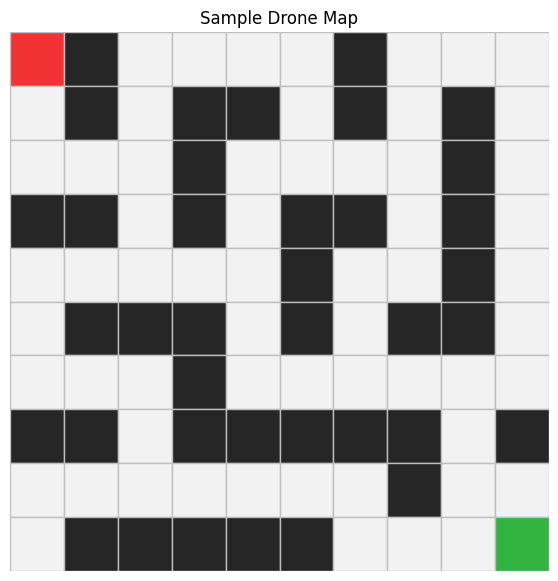

In [71]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")


In [80]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(
                state = s_prime,
                parent = node,
                action = action,
                path_cost = cost,
            )
            
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [81]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        node = Node(problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
            )
            
        # 3.  a deque frontier and add the initial node.
        frontier = deque([node])
        # 4. Create a reached set and add the initial state.
        reached = {node.state}
        nodes_expanded = 0
        max_frontier_size = 1
        # 5. While frontier is not empty:
        while frontier:
        #       a. pop from the LEFT of the deque.
            node = frontier.popleft()
        #       b. increment nodes_expanded.
            nodes_expanded += 1
        #       c. expand the node.
            for child in self.expand(problem, node):
                s = child.state
        
        #       d. for each child:
        #            i. if child is goal, return success.
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),

                     )
                
        #           ii. if child.state is not in reached:
                if s not in reached:
                
        #                  add child.state to reached.
                    reached.add(s)
               
        #                  append child to frontier.
                    frontier.append(child)
        #       e. update max_frontier_size.
                    max_frontier_size = max(max_frontier_size, len(frontier))
        
        # 6. Return failure if no solution is found.
        # 6. Return failure if no solution is found.
        return SearchResult(  
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),

        )

        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()


In [82]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        node = Node(problem.initial_state())     
        
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
            )
            
        # 3. Use a Python list as the stack frontier.
        frontier = [node]
        # 4. Use a reached set.
        reached = {node.state}
        nodes_expanded = 0
        max_frontier_size = 1
        # 5. While frontier is not empty:
        while frontier:
        #       a. pop from the end of the list.
            node = frontier.pop()
        #       b. increment nodes_expanded.
            nodes_expanded += 1
        #       c. expand the node.
            children = list(self.expand(problem, node))
            children.reverse()
        #       d. add unreached children to the stack.
            for child in children:
                s = child.state
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),

                    )

                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
        #       e. update max_frontier_size.
            max_frontier_size = max(max_frontier_size, len(frontier))
            
        return SearchResult(  
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),

        )
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.


In [83]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        if problem.is_goal(node.state):
            return node, "success"
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        if node.depth >= limit:
            return None, "cutoff"
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        metrics["nodes_expanded"] += 1   
        #       b. set cutoff_occurred = False.
        cutoff_occurred = False
        #       c. for each child in expand(problem, node):
        #         i. skip the child if child.state already appears on the current path.
        for child in self.expand(problem, node):
            if state_is_on_path(node, child.state):
                continue  
        #            ii. update max_stack_size.
            new_stack_size = current_stack_size + 1
            metrics["max_stack_size"] = max(metrics["max_stack_size"], new_stack_size)
        #           iii. recursively call _recursive_dls on the child.
            result, status = self._recursive_dls(
                problem = problem,
                node = child,
                limit = limit,
                metrics = metrics,
                current_stack_size = new_stack_size
            )
        #            iv. if result is "success", return success immediately.
            if status == "success":
                return result, "success"
        #             v. if result is "cutoff", set cutoff_occurred = True.
            if status == "cutoff":
                cutoff_occurred = True
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        if cutoff_occurred:
            return None, "cutoff"
        #             else return (None, "failure")
        else:
            return None, "failure"


In [84]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        dls = DepthLimitedSearch()
        iteration_log = []
        # 2. Accumulate total nodes expanded across all DLS iterations.
        total_nodes_expanded = 0
        # 3. Track the maximum stack size seen in any DLS run.
        max_frontier_seen = 0

        for limit in range(max_depth + 1):
            result = dls.search(problem, limit=limit)
            total_nodes_expanded += result.nodes_expanded
            max_frontier_seen = max(max_frontier_seen, result.max_frontier_size)
            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "nodes_expanded": result.nodes_expanded,
            })
        
        # 4. If a DLS run returns success, return a SearchResult for IDS.
            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_frontier_seen,
                    limit=limit,
                    iterations=iteration_log,
                )
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_frontier_seen,
                    limit=limit,
                    iterations=iteration_log,
                )
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_frontier_seen,
            limit=max_depth,
            iterations=iteration_log,
        )
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)


In [85]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,53,6,58
1,DFS,success,NaN,38.0,38.0,38,6,43
2,DLS,cutoff,10.0,NaN,NaN,19,11,0
3,IDS,success,18.0,18.0,18.0,466,19,0


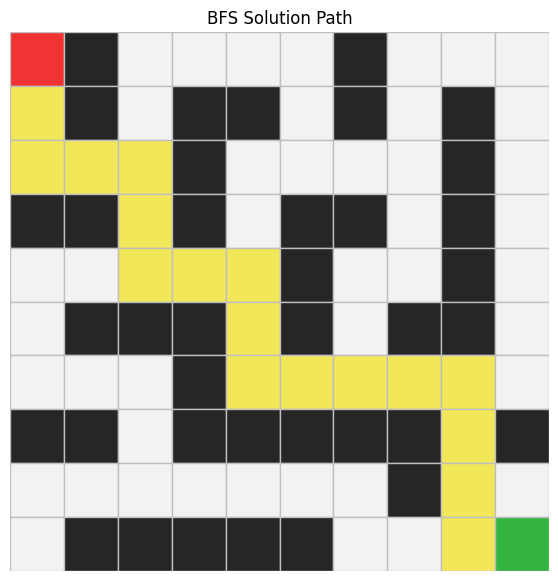

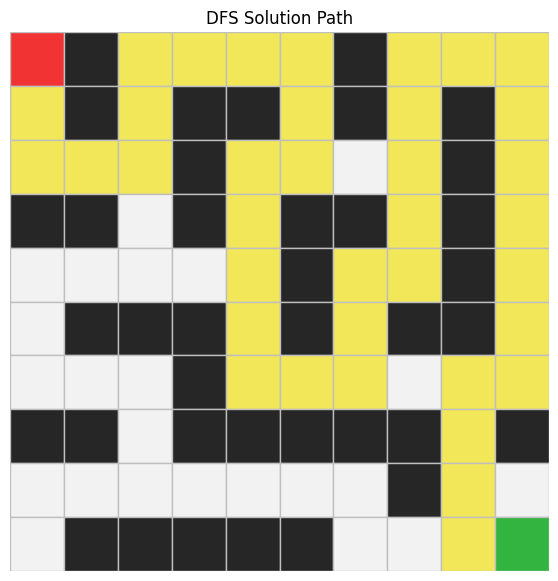

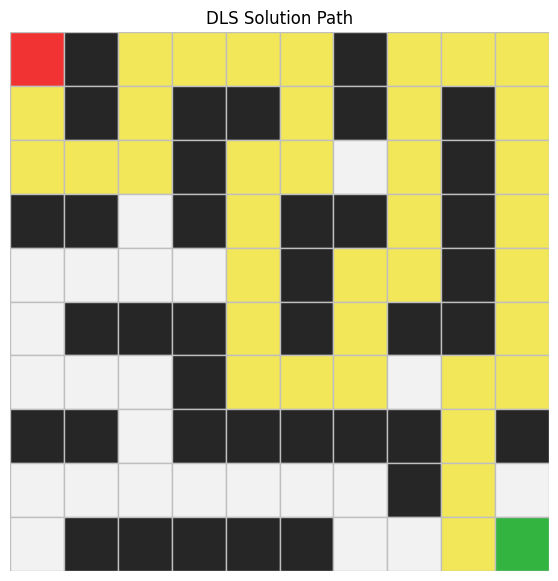

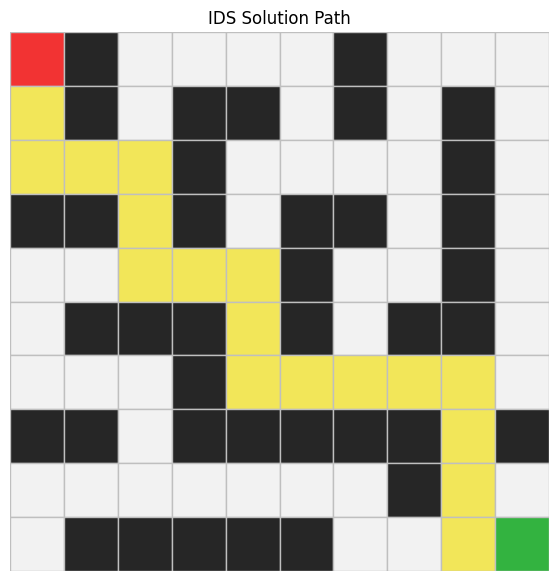

In [110]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]
dls_result = results[1]
ids_result = results[0]



plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)
plot_path(
    sample_grid,
    start,
    goal,
    path=dls_result.path,
    title="DLS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=ids_result.path,
    title="IDS Solution Path",
)
plt.show()

In [88]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0, 0, 0, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0],
    [1, 1, 0, 1, 1],
    [0, 0, 0, 1, 0],
    
]

custom_start_1 = (0, 0)
custom_goal_1 = (4, 4)

# Example after completing:
# custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_problem_1 = GridProblem(
    custom_grid_1,
    custom_start_1,
    custom_goal_1
)
# custom_results_1 = [
#     bfs.search(custom_problem_1),
#     dfs.search(custom_problem_1),
#     dls.search(custom_problem_1, limit=20),
#     ids.search(custom_problem_1, max_depth=40),
# ]
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]

# show_results(custom_results_1)
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,failure,NaN,None,None,15,2,15
1,DFS,failure,NaN,None,None,15,3,15
2,DLS,failure,20.0,None,None,15,9,0
3,IDS,failure,9.0,None,None,70,9,0


In [23]:
'''BFS finds the shortest path efficiently, DFS may go down wrong branches in the corridor before backtracking, DLS performance depends heavily on chosen depth limit and finally IDS behaves like BFS in optimality but uses repeated depth-limited searches.'''

'BFS finds the shortest path efficiently, DFS may go down wrong branches in the corridor before backtracking, DLS performance depends heavily on chosen depth limit and finally IDS behaves like BFS in optimality but uses repeated depth-limited searches.'

In [89]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0, 1, 1, 1, 1],
    [0, 0, 0, 0, 0],
    [1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (4, 4)

# Example after completing:
# custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

# custom_results_2 = [
#     bfs.search(custom_problem_2),
#     dfs.search(custom_problem_2),
#     dls.search(custom_problem_2, limit=20),
#     ids.search(custom_problem_2, max_depth=40),
# ]
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=25),
    ids.search(custom_problem_2, max_depth=50),
]
# show_results(custom_results_2)
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,8,8,8,1,8
1,DFS,success,NaN,8,8,8,1,9
2,DLS,success,25.0,8,8,8,9,0
3,IDS,success,8.0,8,8,36,9,0


In [24]:
'''DFS is likely to explore deep dead ends before reaching the goal, BFS reliably finds the shortest path but uses more memory.
IDS balances memory efficiency with optimality, DLS may fail if the limit is too small or inefficient if too large.'''

'DFS is likely to explore deep dead ends before reaching the goal, BFS reliably finds the shortest path but uses more memory.\nIDS balances memory efficiency with optimality, DLS may fail if the limit is too small or inefficient if too large.'

In [99]:
'''15. Reflection Questions (Answers)
15.1 Problem Formulation
    1. A state in this lab refers to a tuple of row and column (row, col) representing the current position of the drone on the grid.
        It is a complete description of the drone's location at any point in time for example (0, 0) means row 0 and column 0.
    2. An action is one of the four movement directions the drone can make from its current position("UP", "DOWN", "LEFT", "RIGHT"). 
        Not all actions are legal from every state for example, can't move right if there is an obstacle to the right.
    3. The result function applies an action to a state and returns the new state for example result((0, 0), "RIGHT") returns (0, 1).
    4. Because: The problem knows about the specific environment however the searchAlgorithm is generic and does not care what domain it's searching.
        The same BFS algorithm works for grids, puzzles, games, road networks, etc., as long as they implement the Problem interface. This makes code reusable, testable, and maintainable.'''


'15. Reflection Questions (Answers)\n15.1 Problem Formulation\n    1. A state in this lab refers to a tuple of row and column (row, col) representing the current position of the drone on the grid.\n        It is a complete description of the drone\'s location at any point in time for example (0, 0) means row 0 and column 0.\n    2. An action is one of the four movement directions the drone can make from its current position("UP", "DOWN", "LEFT", "RIGHT"). \n        Not all actions are legal from every state for example, can\'t move right if there is an obstacle to the right.\n    3. The result function applies an action to a state and returns the new state for example result((0, 0), "RIGHT") returns (0, 1).\n    4. Because: The problem knows about the specific environment however the searchAlgorithm is generic and does not care what domain it\'s searching.\n        The same BFS algorithm works for grids, puzzles, games, road networks, etc., as long as they implement the Problem interfa

In [100]:
'''15.2 BFS
    1. A FIFO queue ensure that nodes are explored in order of increasing depth. Nodes added first are removed first, ensuring we explore all nodes at depth d before exploring anynodes at
        depth d+1. This give BFS its breadth-first behavior.
    2. Because BFS explores all nodes at depth d before any at depth d+1. The first time BFS finds the goal, it has found a path with the minimum depth.
        And once the goal is found, BFS terminates immediately.
    3. The reached set prevents resiviting the same state in the same search run because it stores the state the drone had visited in a search. Once a state is added to reached, we never expand it again.
        This Ensures the search terminates even in large or infinite state spaces and reduces memory and computation need.'''


'15.2 BFS\n    1. A FIFO queue ensure that nodes are explored in order of increasing depth. Nodes added first are removed first, ensuring we explore all nodes at depth d before exploring anynodes at\n        depth d+1. This give BFS its breadth-first behavior.\n    2. Because BFS explores all nodes at depth d before any at depth d+1. The first time BFS finds the goal, it has found a path with the minimum depth.\n        And once the goal is found, BFS terminates immediately.\n    3. The reached set prevents resiviting the same state in the same search run because it stores the state the drone had visited in a search. Once a state is added to reached, we never expand it again.\n        This Ensures the search terminates even in large or infinite state spaces and reduces memory and computation need.'

In [101]:
'''15.3 DFS
    1. A LIFO stack ensure that the most recently added node is explored next, which gives DFS its depth-first behavior. DFS dives as deep as possible before backtracking, naturally implemented by pushing children onto a stack.
    2. No, DFS can find a very long path before finding a shorter one, because it explores one branch to its full depth before considering alternatives.
    3. When the solution is deep but the branching factor is high. BFS store all nodes at the current frontier which grow exponentially with depth however DFS only stores nodes on the current path which is linear in depth.
    4. The conditions under which DFS can perform badly:
            a. Dead ends: DFS explores entire dead-end branches before backtracking.
            b. Infinite depth: In an infinite state space, DFS may never terminate or may go infinitely deep.
            c. Poor goal location: If the goal is in a rarely visited branch, DFS may explore most of the space first.
            d. Worst-case path length: DFS may find a solution but it's much longer than optimal.'''


"15.3 DFS\n    1. A LIFO stack ensure that the most recently added node is explored next, which gives DFS its depth-first behavior. DFS dives as deep as possible before backtracking, naturally implemented by pushing children onto a stack.\n    2. No, DFS can find a very long path before finding a shorter one, because it explores one branch to its full depth before considering alternatives.\n    3. When the solution is deep but the branching factor is high. BFS store all nodes at the current frontier which grow exponentially with depth however DFS only stores nodes on the current path which is linear in depth.\n    4. The conditions under which DFS can perform badly:\n            a. Dead ends: DFS explores entire dead-end branches before backtracking.\n            b. Infinite depth: In an infinite state space, DFS may never terminate or may go infinitely deep.\n            c. Poor goal location: If the goal is in a rarely visited branch, DFS may explore most of the space first.\n       

In [102]:
'''15.4 DLS 
    1. If the depth limit is smaller than the goal's depth then DLS will reach the depth limit before reaching the goal resulting in a cutoff status and fail to to find a solution.
    2. "cutoff" means: We hit the depth limit without proving the goal doesn't exist. Because the DLS search is a search with limit depth.
    3. DFS has no depth limit, it explores as deep as needed but DLS stop at the fixed depth limit given, it is safe in infinite state space.
    4. Path-cycle checking checks if a state is already on the current path before expanding it. This prevents cycles on the current path and avoids infinite recursion.'''


'15.4 DLS \n    1. If the depth limit is smaller than the goal\'s depth then DLS will reach the depth limit before reaching the goal resulting in a cutoff status and fail to to find a solution.\n    2. "cutoff" means: We hit the depth limit without proving the goal doesn\'t exist. Because the DLS search is a search with limit depth.\n    3. DFS has no depth limit, it explores as deep as needed but DLS stop at the fixed depth limit given, it is safe in infinite state space.\n    4. Path-cycle checking checks if a state is already on the current path before expanding it. This prevents cycles on the current path and avoids infinite recursion.'

In [103]:
'''15. 5 IDS
    1. IDS gradually increases the depth limit until a solution is found unlike DLS which stop at the depth limit. This way the limit grow large enough to find the goal, 
        it finds the shallowest solution first(optimal).
    2. Because IDS use large enough limit to reach the goal. IDS terminates with success when any DLS succeeds.
    3. With BFS frontier grow exponentially but for IDS each iteration uses O(d) memory where d is the current limit. Though IDS does more work (expanding nodes multiple times), it uses much less memory.               
    4. Work overhead: Nodes at shallow depths are re-expanded in every iteration.'''


'15. 5 IDS\n    1. IDS gradually increases the depth limit until a solution is found unlike DLS which stop at the depth limit. This way the limit grow large enough to find the goal, \n        it finds the shallowest solution first(optimal).\n    2. Because IDS use large enough limit to reach the goal. IDS terminates with success when any DLS succeeds.\n    3. With BFS frontier grow exponentially but for IDS each iteration uses O(d) memory where d is the current limit. Though IDS does more work (expanding nodes multiple times), it uses much less memory.               \n    4. Work overhead: Nodes at shallow depths are re-expanded in every iteration.'

In [104]:
'''15.6 Real-World Drone Context
    1. Things that might make one route safer or more practical than another:
        a. Wind exposure: Some routes may be safer in certain weather.
        b. Battery usage: Altitude, terrain roughness, wind affect battery drain.
        c. Signal strength: Staying near base station.
        d. Obstacle avoidance: Some paths safer than others (collisions, turbulence).
        e. No-fly zones: Restricted airspace.
        f. Payload considerations: Some terrain harder for cargo drones.
    2. I would choose BFS because BFS finds the shortest path in term of number of steps on unweighted graphs, and it is optimal and complete when all edge costs are equal. It guarantees the fewest moves to reach the goal.
    3. I would choose DLS, since DLS has a hard depth limit that you specify, DLS will not explore beyond the limit, providing guaranteed bounds.
    4. The limitations:
        a. Discrete grid: Real drones can fly to continuous coordinates, not just grid cells.
        b. Uniform costs: All moves cost 1; real drones have variable energy costs.
        c. Perfect information: We know the entire grid; real drones have sensors with limited range.
        d. No dynamics: Ignores wind, momentum, acceleration; real drones have physics.
        e. 2D only: Real drone navigation is 3D.
        f. No time: Doesn't account for time constraints or scheduling.
        g. Binary obstacles: Obstacles are all-or-nothing; real environments have soft obstacles (e.g., wind-prone areas).
        h. No energy model: Real drones have limited battery.'''


"15.6 Real-World Drone Context\n    1. Things that might make one route safer or more practical than another:\n        a. Wind exposure: Some routes may be safer in certain weather.\n        b. Battery usage: Altitude, terrain roughness, wind affect battery drain.\n        c. Signal strength: Staying near base station.\n        d. Obstacle avoidance: Some paths safer than others (collisions, turbulence).\n        e. No-fly zones: Restricted airspace.\n        f. Payload considerations: Some terrain harder for cargo drones.\n    2. I would choose BFS because BFS finds the shortest path in term of number of steps on unweighted graphs, and it is optimal and complete when all edge costs are equal. It guarantees the fewest moves to reach the goal.\n    3. I would choose DLS, since DLS has a hard depth limit that you specify, DLS will not explore beyond the limit, providing guaranteed bounds.\n    4. The limitations:\n        a. Discrete grid: Real drones can fly to continuous coordinates, n